In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Google_Stock_Price.csv to Google_Stock_Price.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

from tensorflow.keras import Input

In [ ]:
df = pd.read_csv("Google_Stock_Price.csv", thousands = ",")


In [ ]:
data = df['Open'].values.reshape(-1,1)
data = pd.to_numeric(df['Open'], errors = 'coerce').dropna().values.reshape(-1,1)

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)


In [ ]:
train_size = int(len(data_scaled)*0.8)
train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]

In [ ]:
def create_dataset(dataset):
  x = []
  y = []

  for i in range(60,len(dataset)):
    x.append(dataset[i-60:i,0])
    y.append(dataset[i,0])

  return np.array(x) , np.array(y)

In [ ]:
X_train, y_train = create_dataset(train_data)
X_test, y_test = create_dataset(test_data)

In [ ]:
X_train = np.reshape(X_train,(X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test,(X_test.shape[0], X_test.shape[1], 1))

In [ ]:
model = Sequential([
    Input(shape=(60,1)),
    SimpleRNN(50, return_sequences=True),
    SimpleRNN(50),
    Dense(1)
])

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'mse'
)

In [ ]:
model.fit(X_train, y_train, epochs=20, batch_size = 32 )

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0210
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0017
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 7.9524e-04
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 5.6154e-04
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 5.0086e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 4.6836e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 4.6868e-04
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 4.5593e-04
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 3.8559e-04
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3.8972e-04
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 3.6551e-04
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3.5781e-04
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 4.3590e-04
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3.5164e-04
Epoch 15/20
30/30 ━━━━━

In [ ]:
predicted = model.predict(X_test)
predicted = scaler.inverse_transform(predicted)
real = scaler.inverse_transform(y_test.reshape(-1,1))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


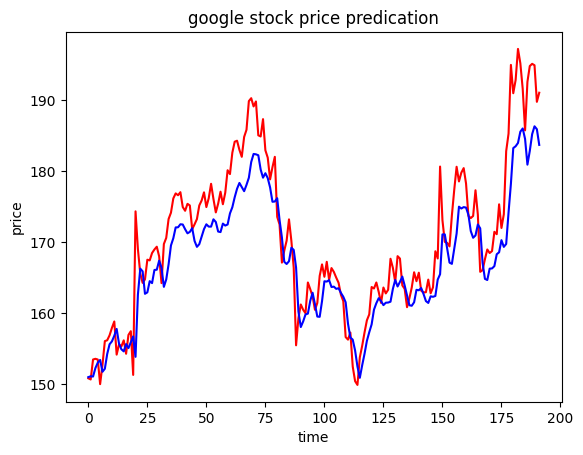

In [ ]:
plt.plot(real , color = 'red', label='real price')
plt.plot(predicted, color='blue', label = 'predicted price')
plt.title("google stock price predication")
plt.xlabel('time')
plt.ylabel('price')
plt.show()